In [1]:
import numpy as np
import xarray as xr
from datetime import datetime, timedelta
import cmocean
from matplotlib import pyplot as plt, animation, rc,colors
from IPython.display import Image
rc('animation', html='html5')
import os

import pandas as pd
import matplotlib.dates as mdates

In [ ]:
M_path = '/home/jvalenti/MOAD/'
coords = xr.open_dataset(M_path+'grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset(M_path+'grid2/mesh_mask202108_TDV.nc')
lon = coords.nav_lon
x= np.linspace(0,lon.shape[1],lon.shape[1])
y = np.linspace(0,lon.shape[0],lon.shape[0])
X,Y = np.meshgrid(x,y)

In [ ]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [ ]:
def make_filename(path_run,start,day, var='prod_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict
    """
    date  =  (start + timedelta(days=day))
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(f'{folder}/', fname[0])


In [ ]:
path_run = '/home/jvalenti/scratch/run_SHEM/long_run/' 
day = 650
start = datetime(2023,1,1)
make_filename(path_run,start,day, var='biol_T', res='h')

'12oct24/SHEM_1h_20241012-20241012_biol_T.nc'

In [ ]:
Ox = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_oxygen
diat = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).diatoms
NO3 = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).nitrate
flag = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).flagellates
hbac = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).heterotrophic_bacteria
DOM = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_organic_nitrogen
POM = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).particulate_organic_nitrogen

In [ ]:
#(imin,imax,jmin,jmax)
regions = {'Jervis':(290,360,610,690),'Sanich':(173,220,325,360),'CSoG':(180,300,450,550),'Dabob Bay':(167,214,120,150), 'Lynch Cove': (120,150,67,76)}
colors_reg={'Jervis':'tab:blue','Sanich':'tab:orange','CSoG':'tab:green','Dabob Bay':'tab:red', 'Lynch Cove': 'tab:purple'}
def mark_region(region,color = 'tab:blue'):
    coords = regions[region]
    x = [coords[0], coords[1], coords[1], coords[0], coords[0]]
    y = [coords[2], coords[2], coords[3], coords[3], coords[2]]
    plt.plot(x, y, color=color,label=region)


/home/jvalenti/MOAD/analysis-jose/.pixi/envs/shem/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


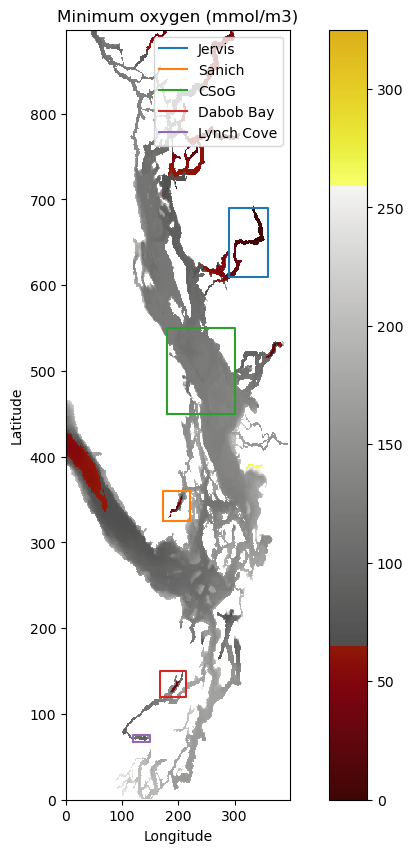

In [ ]:
cmap = cmocean.cm.oxy 

colors=['tab:blue','tab:orange','tab:green','tab:red', 'tab:purple']
fig, ax = plt.subplots(figsize=(10,10))
ox_0 = Ox[0,:,:,:]*mask.tmask[0,0,:,:]
oxy_min = ox_0.where(ox_0 != 0).min(skipna=True,dim='deptht')
plt.pcolormesh(oxy_min,cmap=cmap,vmax =325,vmin=0)
plt.colorbar()
f = 1.0/np.cos(49*np.pi/180)
for i,region in enumerate(regions.keys()):
    mark_region(region,color=colors[i])
plt.legend()
plt.gca().set_aspect(f)
plt.title('Minimum oxygen (mmol/m3)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
#plt.ylim(0,200)
plt.show()

In [ ]:
path_run = '/home/jvalenti/scratch/run_SHEM/long_run/' 
region = None
start = datetime(2023,1,1)
Len = 730
count_hypox = np.zeros(Len)

def hypoxia_count(dia,region=None,regions=None):
    if region is not None:
        x0, x1, y0, y1 = regions[region]
        mbath = mask.mbathy[0,:,:].isel(x=slice(x0,x1),y=slice(y0,y1))-1
    else:
        mbath = mask.mbathy[0,:,:]-1
    total_area = np.sum(mbath>0)
    with xr.open_dataset(path_run+make_filename(path_run,start,dia, var='biol_T', res='h')) as ds:
        if region is not None:
            x0, x1, y0, y1 = regions[region]
            Ox = ds.dissolved_oxygen.isel(time_counter=0,y=slice(y0, y1), x=slice(x0, x1))
        else:
            region = 'full domain'
            Ox = ds.dissolved_oxygen.isel(time_counter=0)
    ox_0 = Ox.isel(deptht=mbath)
    count=np.sum((ox_0 > 0) & (ox_0 < 65))
    return count/total_area

In [ ]:
# for dia in range(Len):
#     if dia==424:
#         continue
#     else: 
#         count_hypox[dia] = 100*hypoxia_count()/total_area.values

#np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_hypox_full.npy', count_hypox)

In [ ]:
count_hypox = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_hypox_full.npy')

In [ ]:
# Len = 730
# count_hypox = np.zeros((len(regions), Len))

# for i, region in enumerate(regions.keys()):
#     print(region)
#     for dia in range(Len):
#         if dia==424:
#             continue
#         else: 
#             count_hypox[i,dia] = hypoxia_count(dia,region=region,regions=regions)
#np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_hypox_regions.npy', count_hypox)


In [ ]:
count_hypox_reg = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_hypox_regions.npy')

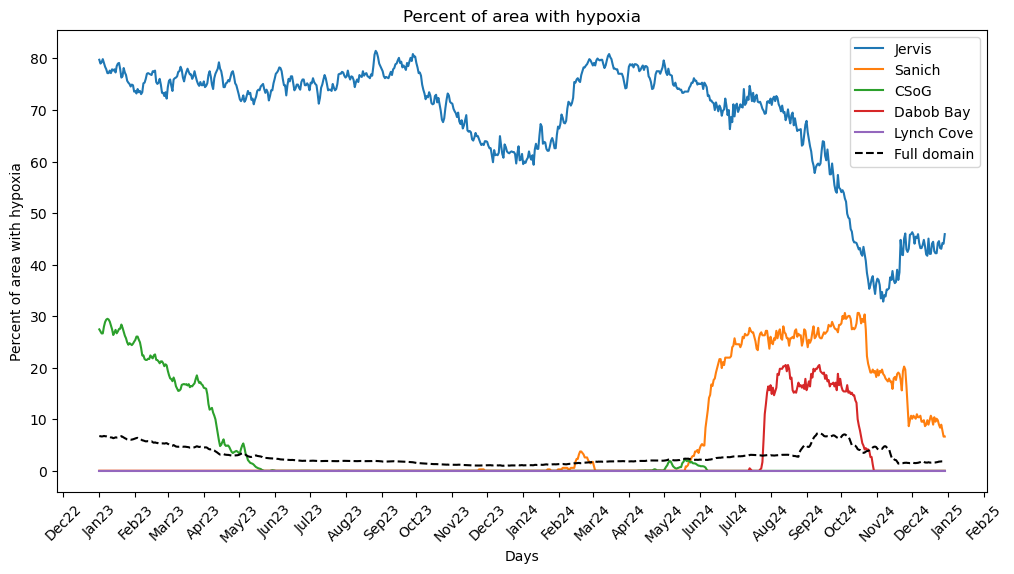

In [ ]:
plt.figure(figsize=(12,6))
time = pd.date_range(start='2023-01-01',end='2024-12-29',freq='D')

for i, region in enumerate(regions.keys()):
    count_hypox_reg[i,424 ]=np.nan
    reg_count = count_hypox_reg[i,~np.isnan(count_hypox_reg[i,:])]
    plt.plot(time, reg_count, label=region, color=colors_reg[region])
count_hypox[424]=np.nan
count = count_hypox[~np.isnan(count_hypox[:])]
plt.plot(time, count, label='Full domain', color='black', linestyle='--')
plt.xlabel('Days')
plt.ylabel('Percent of area with hypoxia')
plt.title('Percent of area with hypoxia')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
plt.xticks(rotation=45)
plt.legend(loc=1)